# Residency Day 2: Advanced Data Mining Project - Deliverable 2

**Name:** Bikram Lamsal  
**Course:** MSCS 634 - Advanced Big Data and Data Mining  
**Title:** Regression Modeling and Performance Evaluation  
**Date:** July 25, 2026

## Deliverable 2: Regression Modeling and Performance Evaluation

This deliverable predicts invoice revenue from engineered invoice-level features. The target variable is `invoice_total`, and the predictors summarize basket size, quantity, product variety, average price, timing, and country.

The main reason for moving from transaction-line data to invoice-level data is that revenue is naturally generated at the invoice or order level. Predicting individual product lines would not answer the business question as directly. By grouping purchases into invoices, the model can learn how basket size, item variety, pricing, time, and geography relate to total order value.

In [1]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("data/invoice_features.csv", parse_dates=["InvoiceDate"])
print(df.shape)
df.head()

(18532, 12)


,InvoiceNo,CustomerID,Country,InvoiceDate,total_quantity,unique_items,line_items,avg_unit_price,invoice_total,InvoiceHour,InvoiceMonth,high_value_invoice
0,536365,17850,United Kingdom,2010-12-01 08:26:00,40,7,7,3.910000,139.12,8,2010-12,0
1,536366,17850,United Kingdom,2010-12-01 08:28:00,12,2,2,1.850000,22.20,8,2010-12,0
2,536367,13047,United Kingdom,2010-12-01 08:34:00,83,12,12,4.853333,278.73,8,2010-12,0
3,536368,13047,United Kingdom,2010-12-01 08:34:00,15,4,4,4.775000,70.05,8,2010-12,0
4,536369,13047,United Kingdom,2010-12-01 08:35:00,3,1,1,5.950000,17.85,8,2010-12,0


In [3]:
# Feature engineering: add calendar fields and log-transform the skewed target.
df["invoice_month_number"] = df["InvoiceDate"].dt.month
df["invoice_dayofweek"] = df["InvoiceDate"].dt.dayofweek
df["log_invoice_total"] = np.log1p(df["invoice_total"])
df[["invoice_total", "log_invoice_total", "total_quantity", "unique_items", "line_items"]].describe().T

,count,mean,std,min,25%,50%,75%,max
invoice_total,18532.0,479.560160,1678.082580,0.380000,157.340000,302.575000,469.570000,168469.600000
log_invoice_total,18532.0,5.588350,1.054715,0.322083,5.064745,5.715629,6.153945,12.034517
total_quantity,18532.0,278.005720,972.389641,1.000000,74.000000,154.000000,290.000000,80995.000000
unique_items,18532.0,20.928178,23.816197,1.000000,6.000000,15.000000,27.000000,541.000000
line_items,18532.0,21.189942,24.348782,1.000000,6.000000,15.000000,27.000000,542.000000


### Feature Engineering Rationale

The original transaction data was aggregated into invoice-level features because the target is invoice revenue. `total_quantity` captures order size, `unique_items` and `line_items` capture basket variety and complexity, `avg_unit_price` captures pricing behavior, and calendar fields capture timing effects. The target is transformed with `log1p` because invoice totals are heavily right-skewed. This transformation reduces the influence of extreme invoices and makes model errors easier to compare.

In [4]:
features = ["total_quantity", "unique_items", "line_items", "avg_unit_price", "InvoiceHour", "invoice_month_number", "invoice_dayofweek", "Country"]
target = "log_invoice_total"
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
numeric_features = [c for c in features if c != "Country"]
categorical_features = ["Country"]
preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

### Modeling Pipeline Rationale

The pipeline separates numeric and categorical preprocessing. Numeric predictors are standardized so coefficient-based models such as Linear Regression and Ridge are not affected by scale differences. `Country` is one-hot encoded because it is categorical and should not be treated as an ordered number. Keeping preprocessing inside the pipeline also prevents data leakage because transformations are learned from the training data during model fitting.

In [5]:
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    cv_rmse = -cross_val_score(model, X, y, cv=5, scoring="neg_root_mean_squared_error").mean()
    return {"model": name, "test_rmse": rmse, "test_r2": r2, "cv_rmse": cv_rmse}

models = {
    "Multiple Linear Regression": Pipeline([("prep", preprocess), ("model", LinearRegression())]),
    "Ridge Regression": Pipeline([("prep", preprocess), ("model", Ridge(alpha=10))]),
    "Random Forest Regression": Pipeline([("prep", preprocess), ("model", RandomForestRegressor(n_estimators=120, max_depth=12, random_state=42, n_jobs=-1))]),
}
results = pd.DataFrame([evaluate_model(name, model) for name, model in models.items()])
results

,model,test_rmse,test_r2,cv_rmse
0,Multiple Linear Regression,0.878261,0.296550,0.908848
1,Ridge Regression,0.879498,0.294567,0.909311
2,Random Forest Regression,0.264807,0.936049,0.267985


### Model Evaluation Rationale

Three regression models are compared to evaluate different levels of complexity. Multiple Linear Regression provides a baseline linear model. Ridge Regression adds regularization to reduce coefficient instability. Random Forest Regression captures nonlinear relationships and feature interactions. RMSE is used because it measures prediction error in the same transformed target scale, R-squared measures explained variance, and cross-validation RMSE checks whether performance is stable across different folds of the data.

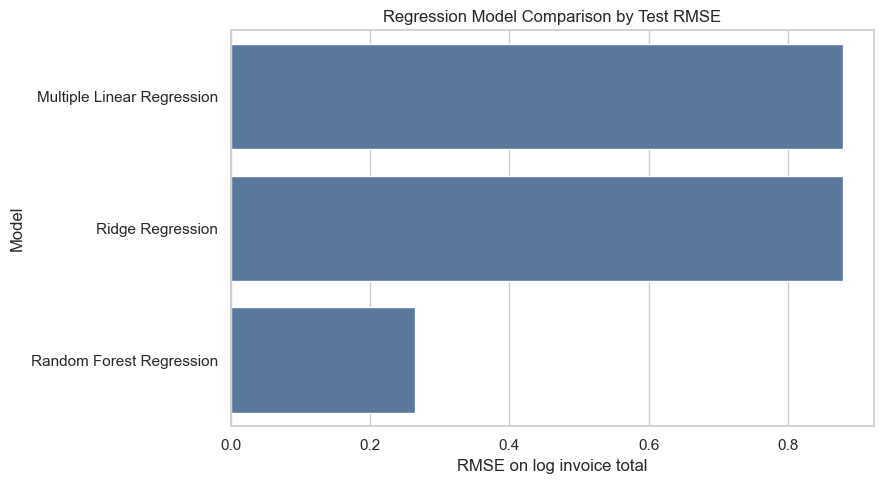

In [6]:
sns.barplot(data=results, x="test_rmse", y="model", color="#4C78A8")
plt.title("Regression Model Comparison by Test RMSE")
plt.xlabel("RMSE on log invoice total")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

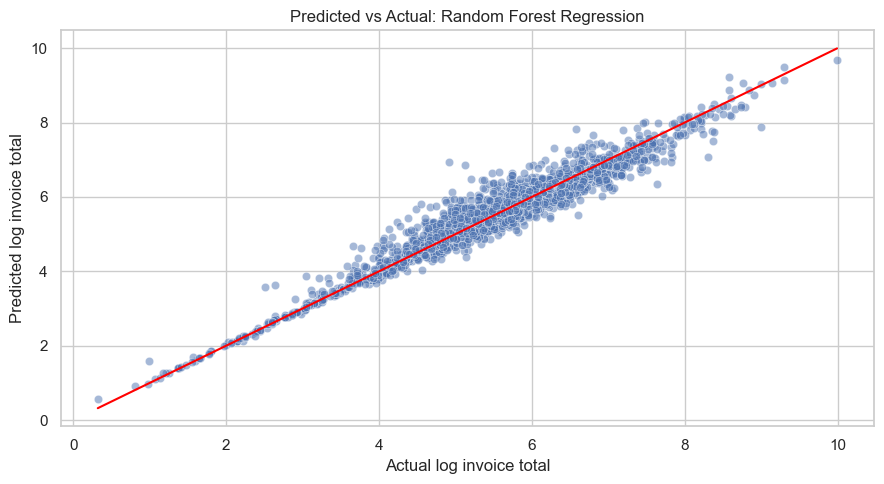

In [7]:
best_name = results.sort_values("test_rmse").iloc[0]["model"]
best_model = models[best_name]
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)
sns.scatterplot(x=y_test, y=preds, alpha=0.5)
min_v = min(y_test.min(), preds.min())
max_v = max(y_test.max(), preds.max())
plt.plot([min_v, max_v], [min_v, max_v], color="red")
plt.title(f"Predicted vs Actual: {best_name}")
plt.xlabel("Actual log invoice total")
plt.ylabel("Predicted log invoice total")
plt.tight_layout()
plt.show()

### Regression Interpretation and Model Selection

This deliverable compares three regression models: Multiple Linear Regression, Ridge Regression, and Random Forest Regression. Multiple Linear Regression is the baseline because it tests whether invoice revenue can be explained with a straightforward linear relationship. Ridge Regression is included as a regularized version of linear regression, which helps control coefficient instability when predictors are related to each other. Random Forest Regression is included as a more flexible nonlinear model that can capture interactions among quantity, item variety, average unit price, country, and invoice timing.

The results show that Random Forest Regression performed best. It produced the lowest test RMSE (`0.2648`) and the highest test R-squared (`0.9360`), while Multiple Linear Regression and Ridge Regression had much higher RMSE values around `0.878` and R-squared values around `0.29`. The cross-validation RMSE also supports this choice because Random Forest had a much lower CV RMSE (`0.2680`) than the two linear models.

Based on these results, Random Forest Regression is selected as the preferred model for prediction. The linear models remain useful as interpretable baselines, but they do not capture the nonlinear retail purchasing patterns as well. The outcome suggests that invoice revenue depends on combined effects between basket size, product variety, pricing, country, and timing rather than a simple linear relationship alone. The selected model is useful for revenue forecasting and invoice prioritization, but it should still be monitored over time because retail behavior can shift seasonally or as customer purchasing patterns change.